In [122]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from dataset import WaveletDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from dataset import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [134]:
print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


 37%|███▋      | 794/2130 [00:41<01:09, 19.36it/s]


In [ ]:
print(finetune_eval_dataset[0]['graph'].x.shape)
print(finetune_eval_dataset[0]['delta'].shape)
print(finetune_eval_dataset[0]['theta'].shape)
print(finetune_eval_dataset[0]['alpha'].shape)
print(finetune_eval_dataset[0]['beta'].shape)
print(finetune_eval_dataset[0]['gamma'].shape)

(19, 1280)
torch.Size([19, 41])
torch.Size([19, 41])
torch.Size([19, 81])
torch.Size([19, 161])
torch.Size([19, 320])


In [ ]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=128, num_workers=2, shuffle=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=128, num_workers=2, shuffle=True)
print(len(finetune_train_loader), len(finetune_eval_loader))

2103 240


In [ ]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, patch_size, heads, seq_len, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels
        self.channel_dropout = nn.Dropout1d(0.1)
        self.patch_size = patch_size
        self.stride = self.patch_size // 2
        self.device = device
        self.heads = heads
        self.encoded_h = encoded_h
        self.seq_len = seq_len

        self.act = nn.GELU()
        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.patch_size) + 1

        '''
        self.patch_embedder1 = nn.Sequential(
            nn.Conv1d(in_channels=self.num_channels, out_channels=self.num_channels, kernel_size=self.patch_size, stride=self.patch_size),
        ).to(self.device)
        '''
        
        #self.gnn_channel_encoder = SplineConv(L_out, self.seq_len, dim=1, kernel_size=3).to(self.device)
        self.gnn_channel_encoder = GATConv(self.seq_len, self.seq_len, heads=self.heads, concat=False).to(self.device)

        L_out = self.seq_len + 2 * (0) - 1 * (self.patch_size - 1) - 1
        L_out = floor(L_out / self.stride) + 1

        self.patch_embedder2 = nn.Sequential(
            # 101 is what they used in BIOT
            nn.Conv1d(in_channels=1, out_channels=101, kernel_size=self.patch_size, stride=self.stride),
        ).to(self.device)
        self.patch_embedder_lin = nn.Sequential(self.act, nn.Linear(101, encoded_h))

        '''
        self.learnable_mask = torch.nn.Parameter(torch.randn(self.encoded_h, requires_grad=True))
        self.transformer_decoder1 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.transformer_decoder2 = nn.TransformerDecoderLayer(self.encoded_h, nhead=2, dim_feedforward=self.encoded_h, activation=nn.GELU(), batch_first=True).to(self.device)
        self.decoder3 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=self.num_channels, kernel_size=19, stride=1)
        L_out = (self.num_channels*L_out) * 1 - 2 * 0 + 1 * (19 - 1) + 0
        self.decoder4 = nn.Sequential(nn.Linear(L_out, L_out), self.act)
        self.decoder5 = nn.Linear(L_out, seq_len)
        '''

    def getEncoderParamCount(self):
        gnn_encoder_count = sum(p.numel() for p in self.gnn_encoder.parameters() if p.requires_grad)
        return gnn_encoder_count

    def getDecoderParamCount(self):
        transformer_decoder1_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        transformer_decoder2_count = sum(p.numel() for p in self.transformer_decoder1.parameters() if p.requires_grad)
        return transformer_decoder1_count + transformer_decoder2_count

    def forward(self, graph, x):
        # x: [Batch Size, Channels, Time Steps]
        emb_seq = []
        x = self.channel_dropout(x)

        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_channel_encoder_input = x.view(-1, x.shape[-1])
        channel_encoding = self.gnn_channel_encoder(gnn_channel_encoder_input, edge_index, edge_dist)
        x = x + channel_encoding.view(x.shape[0], -1, channel_encoding.shape[-1])
        for i in range(x.shape[1]):
            channelwise_patch = x[:, i:i+1, :]
            patch_embedding = self.patch_embedder2(channelwise_patch)
            patch_embedding = patch_embedding.permute(0, 2, 1)
            patch_embedding = self.patch_embedder_lin(patch_embedding)
            emb_seq.append(patch_embedding)

        # emb_seq: [Batch Size, 19 * L_out, patch_size]
        emb_seq = torch.cat(emb_seq, dim=1)

        '''
        masked_emb_seq = emb_seq.clone()
        for batch_idx in range(masked_emb_seq.shape[0]):
            mask_indices = torch.randperm(emb_seq.shape[1])[:int(emb_seq.shape[1] * .1)]
            for mask_idx in mask_indices:
                masked_emb_seq[batch_idx, mask_idx, :] = self.learnable_mask

        decoding_tgt = masked_emb_seq.to(self.device)
        decoding = self.transformer_decoder1(tgt=decoding_tgt, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding + decoding_tgt
        decoding_skip = self.transformer_decoder2(tgt=decoding, memory=masked_emb_seq)
        # Skip Connnection
        decoding = decoding_skip + decoding
        decoding = decoding.permute(0, 2, 1)
        decoding = self.decoder3(decoding)
        # Skip Connection
        decoding = decoding + self.decoder4(decoding) 
        decoding = self.decoder5(decoding) 
        '''
        return emb_seq, emb_seq


'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=10,
                    encoded_h=5,
                    heads=4,
                    seq_len=41,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=10,
                    encoded_h=5,
                    heads=4,
                    seq_len=41,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=20,
                    encoded_h=10,
                    heads=4,
                    seq_len=81,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size=40,
                    encoded_h=20,
                    heads=4,
                    seq_len = 161,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    patch_size = 80,
                    encoded_h = 40,
                    heads=4,
                    seq_len=320,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [ ]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

In [ ]:
class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super(FinetuneDecoder, self).__init__()
        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.Linear(19 * 7 * 5, 7 * 5), nn.GELU(), nn.Dropout(0.1)),
            'theta': nn.Sequential(nn.Linear(19 * 7 * 5, 7 * 5), nn.GELU(), nn.Dropout(0.1)),
            'alpha': nn.Sequential(nn.Linear(19 * 7 * 10, 7 * 10), nn.GELU(), nn.Dropout(0.1)),
            'beta': nn.Sequential(nn.Linear(19 * 7 * 20, 7 * 20), nn.GELU(), nn.Dropout(0.1)),
            'gamma': nn.Sequential(nn.Linear(19 * 7 * 40, 7 * 40), nn.GELU(), nn.Dropout(0.1)),
        })

        self.final_decoder = nn.Linear(80 * 7, 1)

    def forward(self, x):
        band_decodings = []
        for band, (encodings, decodings) in x.items():
            encodings = encodings.view(encodings.shape[0], -1)
            band_decoding = self.band_decoders[band](encodings)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)

        return self.final_decoder(band_decodings)



In [111]:
model = EncoderDecoder(device).to(device)
model_decoder = FinetuneDecoder(device).to(device)
#state_dict = torch.load("/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")
#model.load_state_dict(state_dict)
optim_params = []
optim_params += list(model.parameters())
optim_params += list(model_decoder.parameters())
optimizer = MixOptimizer(torch.optim.Adam(optim_params, lr=1e-3))
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))

Total parameters: 583597
Total parameters: 2002771


In [112]:
def train_one_epoch(model, decoder, optimizer, task_loss_fn, train_loader):
	loss_sum = 0
	model.train()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		data = next(data_iterator)

		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		relevant_bands = [_std_norm(x) for x in relevant_bands]

		inputs = dict(zip(BANDS, relevant_bands))
		encoder_outputs = model(data['graph'], inputs)
		prediction = decoder(encoder_outputs).float()
		ground_truth = data['graph'].y.to(device).float()

		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		balanced_accuracies.append(balanced_accuracy)

		loss = task_loss

		optimizer.scheduler_step(iteration)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return loss_sum

In [115]:
def validate_one_epoch(model, decoder, task_loss_fn, val_loader):
	loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	balanced_accuracies = []

	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)

			relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]

			relevant_bands = [_std_norm(x) for x in relevant_bands]

			inputs = dict(zip(BANDS, relevant_bands))
			encoder_outputs = model(data['graph'], inputs)
			prediction = decoder(encoder_outputs).float()
			ground_truth = data['graph'].y.to(device).float()

			task_loss = task_loss_fn(prediction, ground_truth[:, None])

			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			try:
				roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
				precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
				pr_auc = auc(recall, precision)
			except:
				roc_auc = 0
				pr_auc = 0

			balanced_accuracies.append(balanced_accuracy)

			loss = task_loss
			loss_sum += loss.item()

			pbar.set_postfix(task_loss=task_loss.item(), accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		balanced_accuracies = np.array(balanced_accuracies)
		balanced_accuracies.mean(), balanced_accuracies.std()
		print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return loss_sum, balanced_accuracies.mean(), balanced_accuracies.std()

In [116]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for epoch_idx in range(10):
    training_loss = train_one_epoch(model, model_decoder, optimizer, nn.BCEWithLogitsLoss(), finetune_train_loader)
    eval_loss, eval_acc, eval_std = validate_one_epoch(model, model_decoder, nn.BCEWithLogitsLoss(), finetune_eval_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", eval_loss)


Training: 100%|██████████| 2103/2103 [07:49<00:00,  4.48it/s, AUCPR=82.990, AUROC=84.821, accuracy=80.882, balanced_accuracy=78.929, lr=0.001, task_loss=0.463]   


Mean Acc: 0.7496969671656126 Acc Std: 0.05241074930413074


Validating: 100%|██████████| 240/240 [00:46<00:00,  5.14it/s, AUCPR=77.196, AUROC=70.833, accuracy=64.286, balanced_accuracy=66.667, lr=0.001, task_loss=0.701]


Mean Acc: 0.7568503401126498 Acc Std: 0.0393519392389513
**************************************************
Epoch: 0
Epoch:  0 Total Training Loss:  1062.0152006447315 Total Validation Loss:  114.07996383309364


Training: 100%|██████████| 2103/2103 [07:47<00:00,  4.50it/s, AUCPR=87.286, AUROC=88.152, accuracy=79.412, balanced_accuracy=78.957, lr=0.001, task_loss=0.434]   


...

Mean Acc: 0.7918271156389654 Acc Std: 0.0514562716118497


Validating: 100%|██████████| 240/240 [00:47<00:00,  5.08it/s, AUCPR=94.097, AUROC=93.750, accuracy=71.429, balanced_accuracy=75.000, lr=0.001, task_loss=0.508]


Mean Acc: 0.7525681814899021 Acc Std: 0.03887808408450174
**************************************************
Epoch: 5
Epoch:  5 Total Training Loss:  915.4006497561932 Total Validation Loss:  116.6323272883892


Training:   0%|          | 7/2103 [00:04<20:47,  1.68it/s, AUCPR=89.678, AUROC=88.378, accuracy=79.688, balanced_accuracy=79.129, lr=0.001, task_loss=0.452]  


KeyboardInterrupt: 

In [118]:
pbar = tqdm.trange(len(finetune_eval_loader), desc="Validating")
data_iterator = iter(finetune_eval_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
decoding_outputs = dict()
output_labels = []
predictions = []

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    relevant_bands = [_std_norm(x) for x in relevant_bands]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = model(data['graph'], inputs)
        prediction = model_decoder(encoder_outputs).float()

        predictions.append(prediction)
        output_labels.append(data['graph'].y)
        for band, (encodings, decodings) in encoder_outputs.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            
            encoding_outputs[band].append(encodings)
            decoding_outputs[band].append(decodings)

Validating: 100%|██████████| 240/240 [00:44<00:00,  5.37it/s]


In [119]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()

delta (30606, 133, 5)
theta (30606, 133, 5)
alpha (30606, 133, 10)
beta (30606, 133, 20)
gamma (30606, 133, 40)


In [120]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
reducer2 = umap.UMAP(n_components=2)

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/5 [00:00<?, ?it/s]

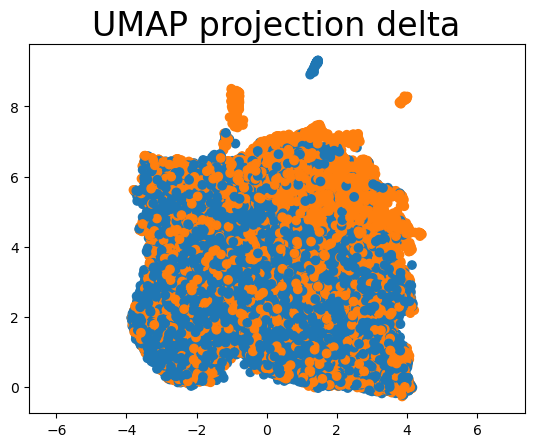

 20%|██        | 1/5 [00:21<01:24, 21.16s/it]

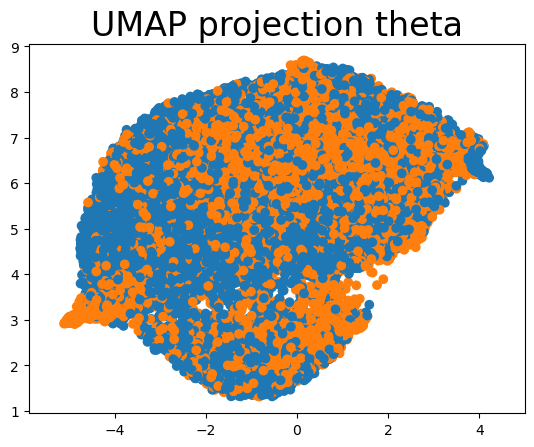

 40%|████      | 2/5 [00:27<00:37, 12.55s/it]

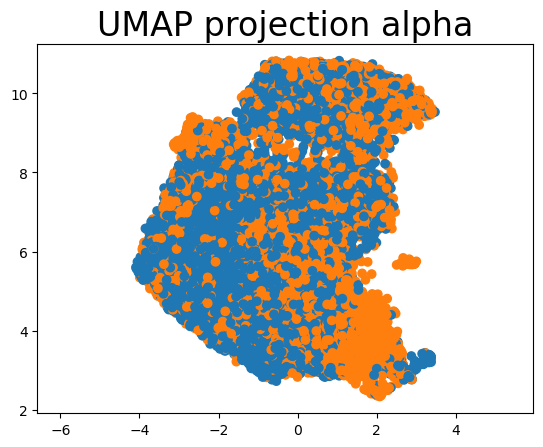

 60%|██████    | 3/5 [00:35<00:20, 10.23s/it]

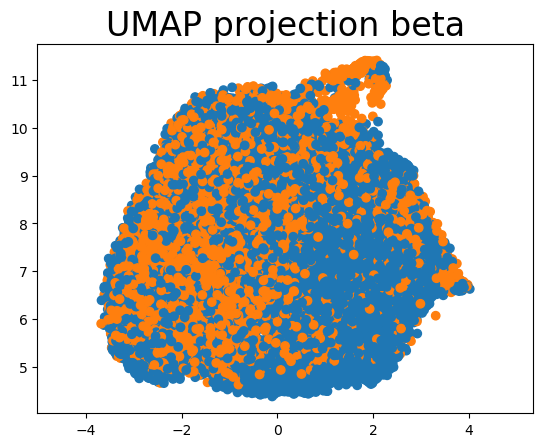

 80%|████████  | 4/5 [00:44<00:10, 10.04s/it]

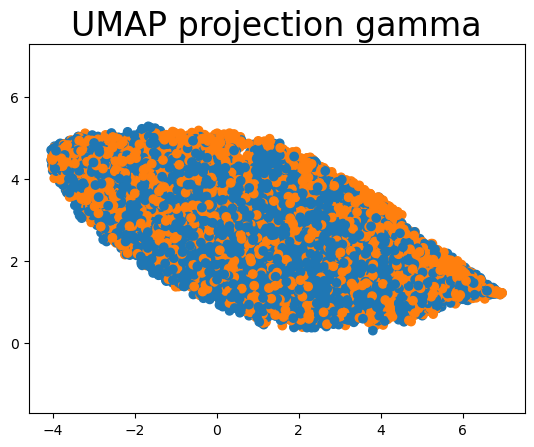

100%|██████████| 5/5 [00:58<00:00, 11.71s/it]


In [121]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma']):
    data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
    embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all])
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()